# 07 — Baseline en el entorno del starter kit

El profesor entregó un **starter kit** con un entorno cinemático de persecución
(`workspace/agente_cero_mc_control_persecucion.ipynb`). Como P1 consiste en tareas acotadas, usamos ese entorno
como **tarea principal** (`src/kit_env.py`, fiel al kit):
- `DASH 100` avanza exactamente 1.0 m y `DASH 50` 0.5 m; `TURN ±35` gira exactamente ±35°;
- sin inercia ni ruido, balón inmóvil;
- el agente observa la distancia y el rumbo verdaderos en cada paso.

Evaluamos con dos distribuciones de inicio:
- **[5, 40] m:** $d_0$ uniforme sobre el rango del enunciado, con posición y orientación arbitrarias. Es la
  distribución de entrenamiento y de la evaluación periódica.
- **Reset del kit:** jugador cerca de (−15, 0) y balón cerca del centro, $d_0 \approx$ 11–19 m, tal como lo
  define el notebook del profesor. Se evalúa con la Q-table final.

Recompensa, $\gamma = 0.99$, 40 pasos por episodio y criterio de captura ($d \le 0.8$ m) son los del enunciado.
La física real de `rcssserver` (notebooks 01–06) queda como **validación de transferencia** (§6).

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
os.chdir("/workspace") if os.path.isdir("/workspace/src") else None
from src import plots
from src.agents import GreedyQPolicy, MonteCarloAgent
from src.controllers import rollout
from src.discretizer import Discretizer, DiscretizerConfig
from src.kit_env import KitBallPursuitEnv
from src.live_eval import episode_record
from src.sampler import evaluation_starts, kit_start
from src.train import KIT_DISCRETIZATIONS, run_episode

ART = "notebooks/artifacts"
def summary_rows(root, names=None):
    rows = []
    for name, rs in plots.load_runs(root).items():
        l5 = [np.mean([e["capture_rate_lt40"] for e in r["evals"][-5:]]) for r in rs]
        worst = min(min(e["capture_rate_lt40"] for e in r["evals"][-5:]) for r in rs)
        kit = [r["final_eval_kit"]["capture_rate_lt40"] for r in rs]
        rows.append(f"| {(names or {}).get(name, name)} | {np.mean(l5):.1%} ± {np.std(l5):.1%} | {worst:.1%} | "
                    f"{np.mean(kit):.1%} ± {np.std(kit):.1%} | {min(kit):.1%} |")
    return rows
HEAD = ["| configuración | [5, 40] m: últimas 5 | peor | reset del kit: final | peor semilla |", "|---|---|---|---|---|"]

## 1. Fidelidad al kit y variabilidad entre semillas

Configuración del notebook del kit: MC Control first-visit, 3 500 episodios,
$\varepsilon = \max(0.05,\ 0.998^k)$, discretización del kit y su propio reset. La repetimos con 8 semillas
usando `src/kit_env.py`. El resultado depende mucho de la semilla, así que un resultado de una sola semilla no es
representativo.

In [2]:
disc_kit = Discretizer(KIT_DISCRETIZATIONS["kitdisc"])
rows = ["| semilla | éxito greedy (reset del kit, 500 ep.) | pasos medios |", "|---|---|---|"]
vals = []
for seed in range(8):
    env = KitBallPursuitEnv(seed=seed); rng = np.random.default_rng(seed)
    agent = MonteCarloAgent(disc_kit.n_states, 4, gamma=0.99, seed=seed)
    for ep in range(3500):
        run_episode(env, agent, disc_kit, max(0.05, 0.998 ** ep), start=kit_start(rng))
    ev = [run_episode(env, agent, disc_kit, 0.0, learn=False, start=s) for s in evaluation_starts(500, 99, law="kit")]
    p = np.mean([r["captured"] for r in ev]); vals.append(p)
    rows.append(f"| {seed} | {p:.1%} | {np.mean([r['steps'] for r in ev]):.1f} |")
rows.append(f"| **media ± desv.** | **{np.mean(vals):.1%} ± {np.std(vals):.1%}** | |")
display(Markdown("\n".join(rows)))

| semilla | éxito greedy (reset del kit, 500 ep.) | pasos medios |
|---|---|---|
| 0 | 100.0% | 22.3 |
| 1 | 98.4% | 24.6 |
| 2 | 95.8% | 25.0 |
| 3 | 95.0% | 27.8 |
| 4 | 86.2% | 28.9 |
| 5 | 44.8% | 34.6 |
| 6 | 97.0% | 27.7 |
| 7 | 96.8% | 24.4 |
| **media ± desv.** | **89.2% ± 17.2%** | |

## 2. Representación del estado

Q-Learning con $\varepsilon$ decreciente 1.0 → 0.1, 20 000 episodios y 5 semillas. Se comparan la discretización
del kit (cortes en 0.8/3/8 m y 15°/60°) y la nuestra sin el bit de velocidad (3/10/20 m y ±17.5°/90°), que en el
kit no aporta porque no hay inercia.

In [3]:
names = {"kit_kitdisc_alpha0.03": "del kit, α = 0.03", "kit_kitdisc_alpha0.1": "del kit, α = 0.1",
         "kit_ourdisc_alpha0.03": "nuestra, α = 0.03", "kit_ourdisc_alpha0.1": "nuestra, α = 0.1"}
display(Markdown("\n".join(HEAD + summary_rows(f"{ART}/runs_kit_discretization", names))))

| configuración | [5, 40] m: últimas 5 | peor | reset del kit: final | peor semilla |
|---|---|---|---|---|
| del kit, α = 0.03 | 56.6% ± 4.9% | 28.6% | 77.4% ± 25.6% | 46.0% |
| del kit, α = 0.1 | 56.4% ± 5.7% | 37.8% | 87.7% ± 20.4% | 47.0% |
| nuestra, α = 0.03 | 61.0% ± 0.8% | 57.6% | 99.6% ± 0.0% | 99.6% |
| nuestra, α = 0.1 | 57.2% ± 2.8% | 36.2% | 86.1% ± 16.5% | 64.2% |

Con 20 estados, nuestra representación supera a la del kit, pero en [5, 40] m queda lejos de lo alcanzable.

**Máximo alcanzable (óptimo exacto).** El kit es determinista, así que para cada inicio se puede calcular el
mínimo de pasos hasta capturar sobre **todas** las secuencias de acciones (búsqueda A*, `src/kit_optimal.py`; 1 000
inicios por distribución, sin inicios indeterminados). Es la meta realista con cualquier política.

In [4]:
opt = json.load(open(f"{ART}/kit_optimal.json"))
rows = ["| inicios | máximo alcanzable < 40 pasos | pasos óptimos medios |", "|---|---|---|"]
for law, label in (("uniform", "[5, 40] m"), ("kit", "reset del kit")):
    sm = opt["laws"][law]["summary"]; p = sm["optimal_capture_rate_lt40"]
    rows.append(f"| {label} | **{p:.1%}** (± {np.sqrt(p * (1 - p) / sm['n']):.1%}, n = {sm['n']}, indeterminados: {sm['undetermined']}) | {sm['mean_optimal_steps']:.1f} |")
display(Markdown("\n".join(rows)))

| inicios | máximo alcanzable < 40 pasos | pasos óptimos medios |
|---|---|---|
| [5, 40] m | **87.9%** (± 1.0%, n = 1000, indeterminados: 0) | 23.0 |
| reset del kit | **100.0%** (± 0.0%, n = 1000, indeterminados: 0) | 18.6 |

Con $d_0$ uniforme en [5, 40] m, **ninguna política puede superar el ≈ 88 %** en este entorno; el 90 % no es
alcanzable. Con el reset del kit, el 100 % sí lo es.

**Representaciones más finas.** El problema a larga distancia es de puntería: la tolerancia angular de captura es
$\arcsin(0.8/d)$, solo 2.3° a 20 m y 1.5° a 30 m, mientras que los giros del kit son siempre de 35°. Probamos
rejillas más finas de rumbo cerca del frente y de distancia (α = 0.03 y 0.1; 40 000 episodios y, para las mejores,
80 000).

In [5]:
names = {"kit_ref_R1_alpha0.03": "R1 (28 estados), α = 0.03", "kit_ref_R1_alpha0.1": "R1 (28), α = 0.1",
         "kit_ref_R2_alpha0.03": "R2 (49), α = 0.03", "kit_ref_R2_alpha0.1": "R2 (49), α = 0.1",
         "kit_ref_R3_alpha0.03": "R3 (99), α = 0.03", "kit_ref_R3_alpha0.1": "R3 (99), α = 0.1",
         "kit_ref_R3_alpha0.1_80k": "**R3 (99), α = 0.1, 80 000 episodios**", "kit_ref_R4_alpha0.1_80k": "R4 (150), α = 0.1, 80 000 episodios"}
display(Markdown("\n".join(HEAD + summary_rows(f"{ART}/runs_kit_refinement", names))))
from src.train import KIT_DISCRETIZATIONS as KD
r3 = KD["R3"]
display(Markdown(f"**R3:** bordes de distancia {list(r3.distance_edges)} m; bordes de rumbo ±{list(r3.angle_edges)}°; "
                 f"{Discretizer(r3).n_states - 1} estados, {4 * (Discretizer(r3).n_states - 1)} valores Q."))

| configuración | [5, 40] m: últimas 5 | peor | reset del kit: final | peor semilla |
|---|---|---|---|---|
| R1 (28 estados), α = 0.03 | 60.4% ± 4.8% | 21.2% | 77.9% ± 31.1% | 16.2% |
| R1 (28), α = 0.1 | 56.7% ± 4.5% | 30.6% | 95.9% ± 6.9% | 82.2% |
| R2 (49), α = 0.03 | 24.9% ± 9.8% | 10.0% | 33.7% ± 28.6% | 3.0% |
| R2 (49), α = 0.1 | 64.0% ± 2.8% | 47.2% | 99.6% ± 0.4% | 99.0% |
| R3 (99), α = 0.03 | 75.4% ± 4.4% | 64.6% | 100.0% ± 0.1% | 99.8% |
| R3 (99), α = 0.1 | 84.2% ± 0.6% | 81.0% | 100.0% ± 0.0% | 100.0% |
| **R3 (99), α = 0.1, 80 000 episodios** | 84.7% ± 0.4% | 80.0% | 100.0% ± 0.0% | 100.0% |
| R4 (150), α = 0.1, 80 000 episodios | 81.0% ± 0.8% | 73.6% | 99.6% ± 0.7% | 98.2% |

**R3:** bordes de distancia [3.0, 6.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0] m; bordes de rumbo ±[2.5, 7.5, 17.5, 35.0, 90.0, 180.0]°; 99 estados, 396 valores Q.

Elegimos **R3 con α = 0.1 y 80 000 episodios**: la mejor en [5, 40] m, muy estable entre semillas y con 100 %
en el reset del kit en las 5 semillas. R4, más fina, rinde peor: tiene demasiados estados para el presupuesto.

**Selección interna del algoritmo** (R3, α = 0.1, 80 000 episodios, ε decreciente).

In [6]:
names = {"kit_algo_qlearning": "Q-Learning", "kit_algo_sarsa": "SARSA",
         "kit_algo_mc_first_visit": "MC first-visit", "kit_algo_mc_first_visit_alpha": "MC con α constante"}
display(Markdown("\n".join(HEAD + summary_rows(f"{ART}/runs_kit_final_algorithms", names))))

| configuración | [5, 40] m: últimas 5 | peor | reset del kit: final | peor semilla |
|---|---|---|---|---|
| MC first-visit | 85.3% ± 1.0% | 83.6% | 100.0% ± 0.0% | 100.0% |
| MC con α constante | 45.8% ± 4.8% | 12.8% | 54.0% ± 31.0% | 18.6% |
| Q-Learning | 84.7% ± 0.4% | 80.0% | 100.0% ± 0.0% | 100.0% |
| SARSA | 85.3% ± 0.6% | 79.8% | 100.0% ± 0.0% | 100.0% |

Q-Learning, SARSA y MC first-visit terminan empatados, dentro del ruido entre semillas: ≈ 85 % en [5, 40] m y
100 % con el reset del kit. SARSA y MC alcanzan el 70 % antes. MC con α constante es inestable. Mantenemos
**Q-Learning**, sobre el que se hace la ablación requerida.

## 3. Ablación de exploración: ε constante vs. ε decreciente (Q-Learning)

| exploración | [5, 40] m: final | últimas 5 | peor | episodios hasta 70 % / 80 % | reset del kit | pasos (reset del kit) |
|---|---|---|---|---|---|---|
| ε constante = 0.1 | 84.3% ± 1.3% | 84.9% ± 0.6% | 80.0% | 16000–16000 / 16000–32000 (5/5) | **100.0% ± 0.0%** | 19.3 |
| ε decreciente 1.0 → 0.1 | 85.7% ± 0.3% | 84.7% ± 0.4% | 80.0% | 12000–12000 / 12000–16000 (5/5) | **100.0% ± 0.0%** | 19.1 |

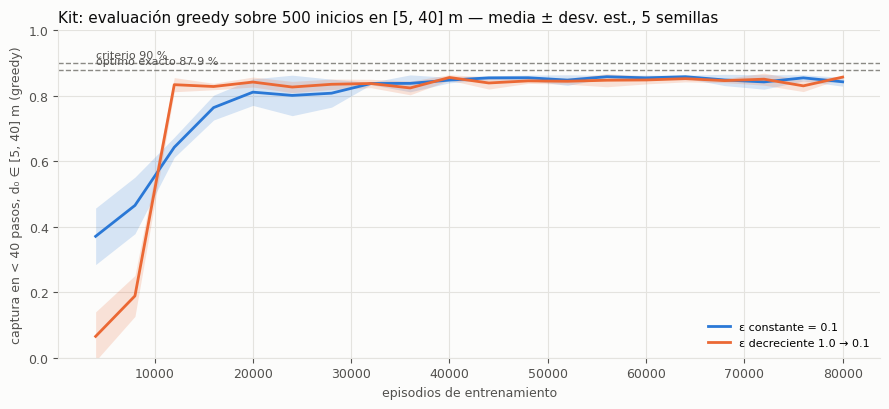

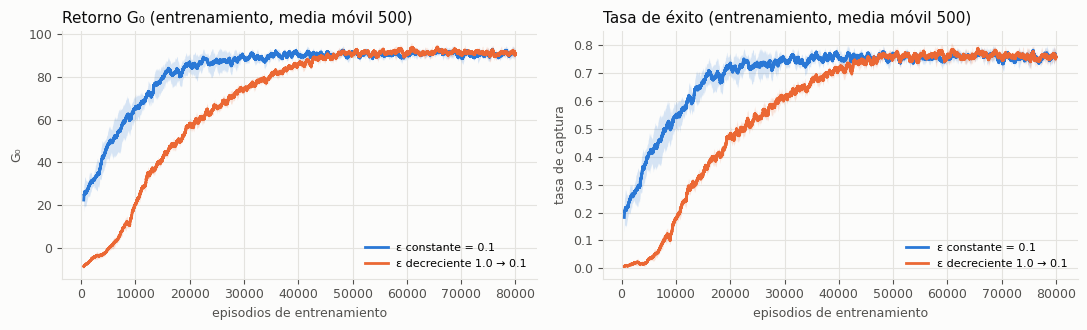

In [7]:
runs = plots.load_runs(f"{ART}/runs_kit_final")
NAMES = {"kit_qlearning_eps_const_0.1": "ε constante = 0.1", "kit_qlearning_eps_decay_1.0_to_0.1": "ε decreciente 1.0 → 0.1"}
lines = ["| exploración | [5, 40] m: final | últimas 5 | peor | episodios hasta 70 % / 80 % | reset del kit | pasos (reset del kit) |",
         "|---|---|---|---|---|---|---|"]
for name, rs in runs.items():
    fin = [r["final_eval"]["capture_rate_lt40"] for r in rs]
    l5 = [np.mean([e["capture_rate_lt40"] for e in r["evals"][-5:]]) for r in rs]
    worst = min(min(e["capture_rate_lt40"] for e in r["evals"][-5:]) for r in rs)
    reach = [next((e["episode"] for e in r["evals"] if e["capture_rate_lt40"] >= 0.70), None) for r in rs]
    reach80 = [next((e["episode"] for e in r["evals"] if e["capture_rate_lt40"] >= 0.80), None) for r in rs]
    kit = [r["final_eval_kit"]["capture_rate_lt40"] for r in rs]
    ks = [r["final_eval_kit"]["mean_steps"] for r in rs]
    ok = [x for x in reach if x]; ok8 = [x for x in reach80 if x]
    lines.append(f"| {NAMES[name]} | {np.mean(fin):.1%} ± {np.std(fin):.1%} | {np.mean(l5):.1%} ± {np.std(l5):.1%} | {worst:.1%} | "
                 f"{min(ok)}–{max(ok)} / {min(ok8)}–{max(ok8)} ({len(ok8)}/5) | **{np.mean(kit):.1%} ± {np.std(kit):.1%}** | {np.mean(ks):.1f} |")
display(Markdown("\n".join(lines)))
fig, ax = plt.subplots(figsize=(9, 4.2))
plots.plot_eval_curves(runs, "capture_rate_lt40", refs={"criterio 90 %": 0.9, "óptimo exacto 87.9 %": 0.879}, ax=ax, labels=NAMES, direct_labels=False,
                       ylabel="captura en < 40 pasos, d₀ ∈ [5, 40] m (greedy)",
                       title="Kit: evaluación greedy sobre 500 inicios en [5, 40] m — media ± desv. est., 5 semillas")
ax.set_ylim(0, 1)
fig.tight_layout(); fig.savefig(f"{ART}/fig_kit_eval.png", dpi=200)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
plots.plot_training_curve(runs, "return", 500, ax=axes[0], title="Retorno G₀ (entrenamiento, media móvil 500)",
                          ylabel="G₀", labels=NAMES, direct_labels=False)
plots.plot_training_curve(runs, "captured", 500, ax=axes[1], title="Tasa de éxito (entrenamiento, media móvil 500)",
                          ylabel="tasa de captura", labels=NAMES, direct_labels=False)
fig.tight_layout(); fig.savefig(f"{ART}/fig_kit_training.png", dpi=200)

## 4. Política $\hat\pi(s)$ y valor $\hat V(s)$ aprendidos

La corrida con ε decreciente evaluada en el servidor (`live_policy_kit.txt`). Son estimaciones aprendidas, no
óptimos demostrados.

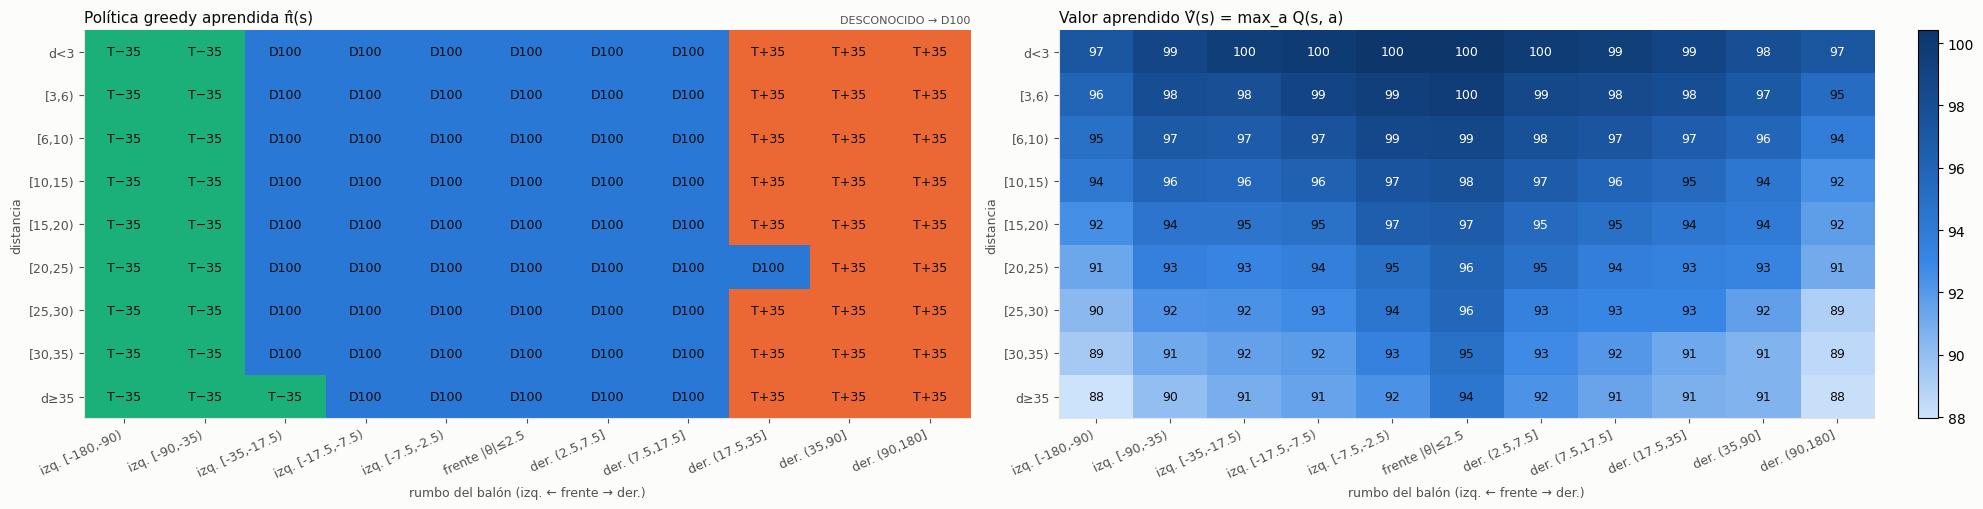

In [8]:
RUN = open(f"{ART}/live_policy_kit_final.txt").read().strip()
cfg = json.load(open(f"{RUN}/config.json"))
disc = Discretizer(DiscretizerConfig.from_dict(cfg["discretizer"]))
Q = np.load(f"{RUN}/q.npy")
fig, axes = plt.subplots(1, 2, figsize=(20, 5.2))
plots.plot_policy(Q, disc, visits=(Q != 0).any(axis=1).astype(int), ax=axes[0])
plots.plot_value(Q, disc, ax=axes[1])
fig.tight_layout(); fig.savefig(f"{ART}/fig_kit_policy_value.png", dpi=200)

La política avanza (`DASH 100`) cuando el balón está entre −35° y +17.5° y gira hacia él fuera de esa ventana,
igual en casi todas las distancias. La ventana es más ancha que un giro de 35°, así que tras girar el balón queda dentro
y el agente no oscila. La corrección fina ocurre por la geometría de la aproximación, no por acciones distintas en
los sectores finos.

## 5. Trayectorias durante el aprendizaje

Q-tables guardadas tras 0, 1 000, …, 80 000 episodios, ejecutadas con su política greedy en el entorno del kit
sobre 4 inicios del reset del kit. Tonos claros = temprano, oscuros = tarde.

     ep_0: capturas 0/4, pasos [40, 40, 40, 40]
  ep_1000: capturas 3/4, pasos [36, 33, 40, 30]
  ep_2000: capturas 2/4, pasos [40, 40, 36, 35]
  ep_5000: capturas 2/4, pasos [35, 40, 29, 40]
 ep_10000: capturas 4/4, pasos [16, 20, 25, 19]
 ep_20000: capturas 4/4, pasos [16, 22, 23, 19]
 ep_40000: capturas 4/4, pasos [16, 21, 23, 19]
 ep_80000: capturas 4/4, pasos [16, 20, 24, 19]


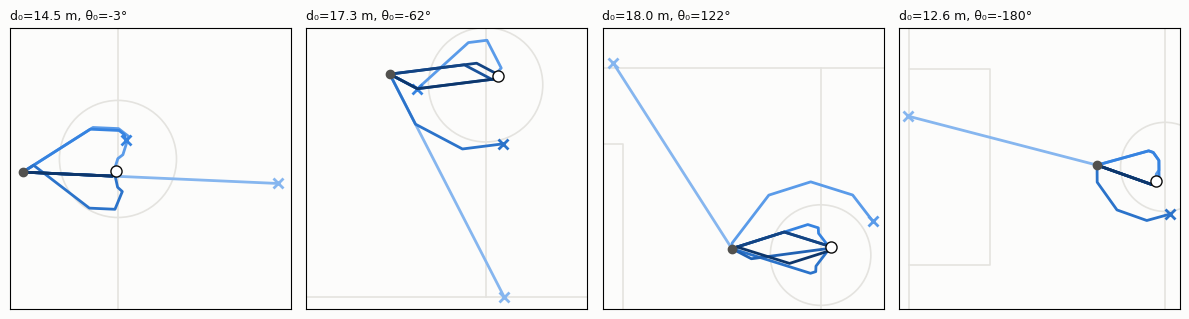

In [9]:
snap_q = np.load(f"{RUN}/q_snapshots.npz")
keys = sorted(snap_q.files, key=lambda k: int(k.split("_")[1]))
pool = evaluation_starts(200, seed=2026, law="kit")
idx = sorted(range(len(pool)), key=lambda i: abs(pool[i].bearing))
idx = [idx[0], idx[len(idx) // 3], idx[2 * len(idx) // 3], idx[-1]]      # delante ... detrás
env = KitBallPursuitEnv()
snaps = {k: {"sim": [episode_record(i, rollout(env, GreedyQPolicy(snap_q[k], disc), pool[i]), True) for i in idx]}
         for k in keys}
for k in keys:
    print(f"{k:>9}: capturas {sum(r['captured'] for r in snaps[k]['sim'])}/4, pasos {[r['steps'] for r in snaps[k]['sim']]}")
fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))
for j, ax in enumerate(axes):
    plots.plot_snapshot_trajectories(snaps, j, "sim", ax=ax, legend=False)
fig.tight_layout(); fig.savefig(f"{ART}/fig_kit_learning_traj.png", dpi=200)

## 6. Política aprendida frente al óptimo, por distancia

Los mismos 1 000 inicios en [5, 40] m del cálculo del óptimo, ejecutados con la política final en el entorno del kit.

In [10]:
per = opt["laws"]["uniform"]["per_start"]
starts = evaluation_starts(len(per), seed=opt["seed"], law="uniform")
env = KitBallPursuitEnv(); pol = GreedyQPolicy(Q, disc)
ours = np.array([(rollout(env, pol, s)["capture_step"] or 99) <= 39 for s in starts])
best = np.array([isinstance(p["min_steps"], int) and p["min_steps"] <= 39 for p in per])
d0 = np.array([p["distance"] for p in per])
rows = ["| distancia inicial | política aprendida | óptimo exacto |", "|---|---|---|"]
for lo, hi in ((5, 10), (10, 20), (20, 30), (30, 35), (35, 40.01)):
    m = (d0 >= lo) & (d0 < hi)
    rows.append(f"| [{lo}, {min(hi, 40):g}) m | {ours[m].mean():.1%} | {best[m].mean():.1%} |")
rows.append(f"| **total** | **{ours.mean():.1%}** | **{best.mean():.1%}** |")
display(Markdown("\n".join(rows)))
print(f"la política alcanza el {ours.mean() / best.mean():.1%} del óptimo en estos inicios")

| distancia inicial | política aprendida | óptimo exacto |
|---|---|---|
| [5, 10) m | 100.0% | 100.0% |
| [10, 20) m | 100.0% | 100.0% |
| [20, 30) m | 100.0% | 100.0% |
| [30, 35) m | 85.7% | 90.5% |
| [35, 40) m | 8.2% | 18.7% |
| **total** | **85.9%** | **87.9%** |

la política alcanza el 97.7% del óptimo en estos inicios


## 7. Transferencia a `rcssserver`

La política entrenada en el kit se ejecuta en el servidor real: inercia, giros que dependen de la velocidad, ruido
y visión parcial. Se evalúa con las mismas dos distribuciones (200 episodios cada una), y en la misma corrida se
evalúa también en nuestro simulador con la física del servidor. Así se mide cuánto rendimiento se pierde al pasar
de la cinemática del kit a la física real.

In [11]:
rows = ["| inicios | entorno | captura < 40 pasos | pasos medios |", "|---|---|---|---|"]
for law, f in (("reset del kit", "live_eval_kit_final_kitreset_200.json"), ("[5, 40] m", "live_eval_kit_final_uniform_200.json")):
    r = json.load(open(f"{ART}/{f}"))
    for env_name, label in (("live", "servidor rcssserver"), ("sim", "simulador con física del servidor")):
        eps = [e for e in r[env_name] if "error" not in e]
        p = np.mean([(e["capture_step"] or 10**6) <= 39 for e in eps])
        rows.append(f"| {law} | {label} | {p:.1%} (± {np.sqrt(p * (1 - p) / len(eps)):.1%}, n = {len(eps)}) | "
                    f"{np.mean([e['steps'] for e in eps]):.1f} |")
    st = r["summary"]["stats"]
    print(f"{law}: comandos no ejecutados {st['missed_commands']}, errores {sum('error' in e for e in r['live'])}")
display(Markdown("\n".join(rows)))

reset del kit: comandos no ejecutados 0, errores 0
[5, 40] m: comandos no ejecutados 0, errores 0


| inicios | entorno | captura < 40 pasos | pasos medios |
|---|---|---|---|
| reset del kit | servidor rcssserver | 26.0% (± 3.1%, n = 200) | 35.2 |
| reset del kit | simulador con física del servidor | 26.0% (± 3.1%, n = 200) | 35.1 |
| [5, 40] m | servidor rcssserver | 20.5% (± 2.9%, n = 200) | 36.7 |
| [5, 40] m | simulador con física del servidor | 21.0% (± 2.9%, n = 200) | 36.6 |

## 8. Conclusión

- **Criterio con el reset del kit:** Q-Learning con R3 y ε decreciente captura el **100 %** en menos de 40 pasos en
  las 5 semillas, en 19.1 pasos; el óptimo exacto es 18.6.
- **Rango completo del enunciado** ([5, 40] m, $d_0$ uniforme): el 90 % **no es alcanzable** en este entorno,
  porque el óptimo exacto sobre todas las secuencias de acciones es 87.9 %. Nuestra política captura el 85.7 % ± 0.3,
  el 97.5 % de ese máximo.
- **Discretización:** fue el factor decisivo (de 61 % a 86 %). No aislamos qué componente de R3 explica la mejora:
  agregar solo un sector de ±5° (R1) no ayudó. La política final avanza en una ventana asimétrica [−35°, +17.5°] y
  gira fuera de ella; el borde en 35° de R3 permite representar esa ventana.
- **Exploración:** la decreciente aprende antes (80 % en 12 000–16 000 episodios frente a 16 000–32 000) y termina
  algo más alta y estable.
- **Transferencia a `rcssserver`:** baja, 26.0 % con el reset del kit y 20.5 % en [5, 40] m, iguales a las del
  simulador con física del servidor. La cinemática idealizada del kit no representa la física real. Una política
  entrenada con esa física (notebooks 01–03) alcanza 73.5 % en vivo, así que el problema de transferencia está en
  el entorno de entrenamiento, no en la conexión ni en el cliente.